# Audit: ignored labels and NaN validation metrics

This notebook independently checks the **local Sen1Floods11 files**, rather than assuming the earlier explanation is correct.

1. Count usable and ignored pixels in every hand-labelled split.
2. List and visualise validation chips with no usable labels.
3. Extract the actual preprocessing and metric functions from the downloaded example notebook and run them on CPU.
4. Test whether shuffled validation batches can contain no supervised pixels.
5. Compare the mechanism with the saved hand-labelled training history.

Run directly in Jupyter with **Run All**. Requirements: NumPy, rasterio, matplotlib, PyTorch, torchvision and Pillow. No GPU, model, checkpoint loading, training, installation or network access is needed. Data, split CSVs, training notebooks and saved results are only read. Outputs stay in this notebook.

**Limits:** this checks local data and a local copy of the released example code. It does not establish why an annotator ignored a tile, whether the authors noticed an edge case, or the exact shuffled batches used in a historical run. Image appearance alone cannot prove the reason for an annotation.

In [ ]:
from pathlib import Path
from collections import Counter
import ast
import csv
import hashlib
import json
import math
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import torch
import torchvision
from torchvision import transforms
import torchvision.transforms.functional as F
from PIL import Image

torch.set_num_threads(2)
DATASET_ROOT = next(
    (base / relative for base in (Path.cwd(), *Path.cwd().parents)
     for relative in (Path("runtime/datasets/Sen1Floods11/v1.1"), Path("datasets/Sen1Floods11/v1.1"))
     if (base / relative / "data/flood_events/HandLabeled/LabelHand").is_dir()), None)
if DATASET_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside the checkout with Sen1Floods11 at runtime/datasets/Sen1Floods11/v1.1/.")
RUNTIME_ROOT = DATASET_ROOT.parents[2]
STUDY = RUNTIME_ROOT / "experiments/sen1floods11"
HAND = DATASET_ROOT / "data/flood_events/HandLabeled"
SOURCE_NOTEBOOK = DATASET_ROOT / "code/Train.ipynb"
BASELINE_NOTEBOOK = STUDY / "fcnn_training_v2.ipynb"
HISTORY_FILE = STUDY / "runs/results/hand_labeled/training_history.json"
SPLITS = {
    "train": "flood_train_data.csv", "validation": "flood_valid_data.csv",
    "test": "flood_test_data.csv", "bolivia": "flood_bolivia_data.csv",
}
SEED = 42
SHUFFLE_TRIALS = 10000

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def table(rows, columns):
    rows = [[str(row.get(column, "")) for column in columns] for row in rows]
    widths = [max(len(column), max((len(row[i]) for row in rows), default=0)) for i, column in enumerate(columns)]
    print(" | ".join(column.ljust(widths[i]) for i, column in enumerate(columns)))
    print("-+-".join("-" * width for width in widths))
    for row in rows:
        print(" | ".join(value.ljust(widths[i]) for i, value in enumerate(row)))

print("Execution: CPU only; no model inference")
print("NumPy:", np.__version__, "rasterio:", rasterio.__version__)
print("PyTorch:", torch.__version__, "torchvision:", torchvision.__version__)
print("Data:", DATASET_ROOT.relative_to(RUNTIME_ROOT))

Execution: CPU only; no model inference
NumPy: 2.5.3 rasterio: 1.5.1
PyTorch: 2.14.0+cu130 torchvision: 0.29.0+cu130
Data: datasets\Sen1Floods11\v1.1


## 1. Audit raw masks, before any preprocessing

The dataset defines `0` as non-water, `1` as water and `-1` as no-data/not-valid. The baseline maps ignored targets to `255`. We count valid pixels directly from the GeoTIFF, respecting declared nodata and non-finite values. No interpolation or resizing is used for this audit.

A tile with zero valid pixels supplies **no ground truth**; that does not mean the tile is dry. The full per-file results and label hashes remain available in `audit_rows`.

In [ ]:
audit_rows = []
split_pairs = {}
provenance = []
for split, filename in SPLITS.items():
    csv_path = DATASET_ROOT / "splits/flood_handlabeled" / filename
    provenance.append({"file": str(csv_path.relative_to(RUNTIME_ROOT)), "sha256": sha256(csv_path)})
    with csv_path.open(newline="") as stream:
        pairs = [row for row in csv.reader(stream) if row]
    if any(len(row) != 2 for row in pairs):
        raise ValueError(f"Malformed split: {filename}")
    split_pairs[split] = pairs
    for image, label in pairs:
        label_path = HAND / "LabelHand" / label
        if not (HAND / "S1Hand" / image).is_file():
            raise FileNotFoundError(image)
        with rasterio.open(label_path) as src:
            raw = src.read(1)
            declared_valid = src.read_masks(1) != 0
        finite = np.isfinite(raw)
        unexpected = np.unique(raw[finite & ~np.isin(raw, [-1, 0, 1, 255])])
        if unexpected.size:
            raise ValueError(f"Unexpected labels in {label}: {unexpected}")
        valid = declared_valid & finite & np.isin(raw, [0, 1])
        counts = {str(value): int((raw == value).sum()) for value in np.unique(raw[finite])}
        audit_rows.append({"split": split, "image": image, "label": label,
                           "height": raw.shape[0], "width": raw.shape[1],
                           "valid_pixels": int(valid.sum()), "ignored_pixels": int((~valid).sum()),
                           "water_pixels": int((valid & (raw == 1)).sum()),
                           "raw_counts": counts, "nonfinite": int((~finite).sum()),
                           "label_sha256": sha256(label_path)})

summary = []
for split in SPLITS:
    rows = [r for r in audit_rows if r["split"] == split]
    summary.append({"split": split, "tiles": len(rows),
                    "fully_ignored": sum(r["valid_pixels"] == 0 for r in rows),
                    "partly_ignored": sum(r["valid_pixels"] > 0 and r["ignored_pixels"] > 0 for r in rows),
                    "valid_pixels": sum(r["valid_pixels"] for r in rows)})
table(summary, ["split", "tiles", "fully_ignored", "partly_ignored", "valid_pixels"])
validation_rows = [r for r in audit_rows if r["split"] == "validation"]
ignored_validation = [r for r in validation_rows if r["valid_pixels"] == 0]
print("\nFully ignored validation masks:")
table(ignored_validation, ["label", "height", "width", "valid_pixels", "raw_counts", "nonfinite"])
print("\nObserved count:", len(ignored_validation), "(earlier claim: 3; this value is computed, not assumed)")

split      | tiles | fully_ignored | partly_ignored | valid_pixels
-----------+-------+---------------+----------------+-------------
train      | 252   | 1             | 205            | 57041747    
validation | 89    | 3             | 67             | 20294725    
test       | 90    | 1             | 73             | 20517367    
bolivia    | 15    | 0             | 14             | 2867815     

Fully ignored validation masks:
label                      | height | width | valid_pixels | raw_counts     | nonfinite
---------------------------+--------+-------+--------------+----------------+----------
Ghana_5079_LabelHand.tif   | 512    | 512   | 0            | {'-1': 262144} | 0        
Ghana_234935_LabelHand.tif | 512    | 512   | 0            | {'-1': 262144} | 0        
Ghana_277_LabelHand.tif    | 512    | 512   | 0            | {'-1': 262144} | 0        

Observed count: 3 (earlier claim: 3; this value is computed, not assumed)


## 2. Inspect the affected chips

Each row shows radar VV, optical RGB and the raw label mask. Magenta means missing imagery; grey in the mask means ignored ground truth. The images help inspect the scene, but do not explain the annotator's decision by themselves.

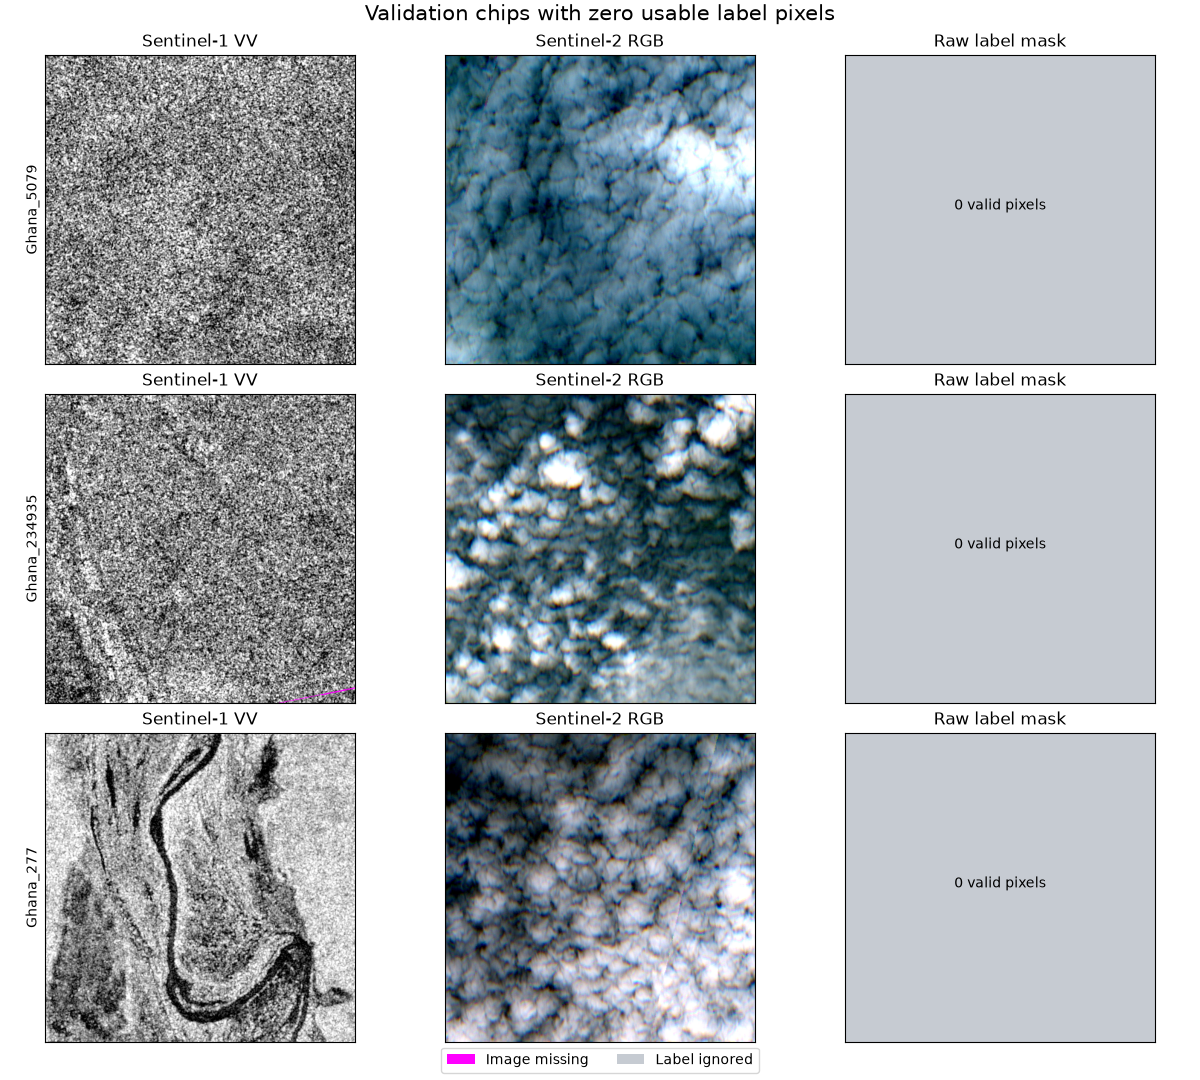

In [ ]:
def read_image(path, bands):
    with rasterio.open(path) as src:
        indices = [list(src.descriptions).index(band) + 1 for band in bands]
        return src.read(indices, masked=True).astype(np.float32).filled(np.nan)

def stretch(array):
    valid = np.isfinite(array)
    result = np.full_like(array, np.nan)
    if valid.any():
        lo, hi = np.percentile(array[valid], [2, 98])
        result[valid] = np.clip((array[valid] - lo) / (hi - lo), 0, 1) if hi > lo else 0
    return result

radar_cmap = plt.get_cmap("gray").copy()
radar_cmap.set_bad("magenta")
mask_cmap = ListedColormap(["#c6cbd2", "#eee6d4", "#168bd2"])
for start in range(0, len(ignored_validation), 3):
    rows = ignored_validation[start:start + 3]
    fig, axes = plt.subplots(len(rows), 3, figsize=(12, 3.6 * len(rows)), squeeze=False, layout="constrained")
    fig.suptitle("Validation chips with zero usable label pixels", fontsize=15)
    for i, row in enumerate(rows):
        key = row["image"].removesuffix("_S1Hand.tif")
        vv = read_image(HAND / "S1Hand" / row["image"], ["VV"])[0]
        rgb_path = HAND / "S2Hand" / (key + "_S2Hand.tif")
        axes[i, 0].imshow(np.ma.masked_invalid(stretch(vv)), cmap=radar_cmap, vmin=0, vmax=1)
        if rgb_path.is_file():
            rgb = np.moveaxis(stretch(read_image(rgb_path, ["B4", "B3", "B2"])), 0, -1)
            rgb[~np.isfinite(rgb).all(axis=-1)] = (1., 0., 1.)
            axes[i, 1].imshow(rgb)
        else:
            axes[i, 1].text(0.5, 0.5, "No optical file", ha="center")
        with rasterio.open(HAND / "LabelHand" / row["label"]) as src:
            raw = src.read(1, masked=True).astype(np.float32).filled(np.nan)
        axes[i, 2].imshow(np.where(np.isin(raw, [0, 1]), raw, -1), cmap=mask_cmap,
                          norm=BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3), interpolation="nearest")
        axes[i, 0].set_ylabel(key)
        axes[i, 2].text(0.5, 0.5, f"{row['valid_pixels']} valid pixels", transform=axes[i, 2].transAxes, ha="center")
        for j, title in enumerate(["Sentinel-1 VV", "Sentinel-2 RGB", "Raw label mask"]):
            axes[i, j].set_title(title)
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
    fig.legend(handles=[Patch(facecolor="magenta", label="Image missing"),
                        Patch(facecolor="#c6cbd2", label="Label ignored")],
               loc="outside lower center", ncol=2)
    plt.show()
    plt.close(fig)
if not ignored_validation:
    print("No fully ignored validation chips found in this copy.")

## 3. Inspect the downloaded example code

The source is the local `v1.1/code/Train.ipynb`, not our plotting code. We read its JSON and extract named function definitions with Python's AST. We do **not** execute its installation, download, model-creation or training cells.

For the metric reproduction only, `.cuda()` calls are removed so the same calculations run on CPU. No metric formula is changed. The example's label loading maps `-1` to `255` before calling `processTestIm`; we apply that mapping while preserving the raster dtype, then call the extracted preprocessing function. This checks that the no-data labels really survive preprocessing.

In [ ]:
def notebook_tree(path):
    notebook = json.loads(path.read_text(encoding="utf-8"))
    nodes = []
    for cell in notebook["cells"]:
        if cell["cell_type"] != "code":
            continue
        source = "".join(cell["source"])
        try:
            nodes.extend(ast.parse(source).body)
        except SyntaxError:
            # Installation/magic cells are not executed or used for extraction.
            continue
    return nodes

class CPUOnly(ast.NodeTransformer):
    def visit_Call(self, node):
        node = self.generic_visit(node)
        if isinstance(node.func, ast.Attribute) and node.func.attr == "cuda":
            return node.func.value
        return node

def extract_functions(path, names, namespace, cpu_only=False):
    definitions = {node.name: node for node in notebook_tree(path) if isinstance(node, ast.FunctionDef)}
    missing = set(names) - set(definitions)
    if missing:
        raise ValueError(f"Missing functions in {path.name}: {missing}")
    selected = ast.Module(body=[definitions[name] for name in names], type_ignores=[])
    if cpu_only:
        selected = CPUOnly().visit(selected)
    exec(compile(ast.fix_missing_locations(selected), str(path.name), "exec"), namespace)
    return definitions

original = {"torch": torch, "transforms": transforms, "F": F, "Image": Image, "np": np}
original_definitions = extract_functions(SOURCE_NOTEBOOK,
    ["processTestIm", "computeAccuracy", "computeIOU"], original, cpu_only=True)
provenance.append({"file": str(SOURCE_NOTEBOOK.relative_to(RUNTIME_ROOT)), "sha256": sha256(SOURCE_NOTEBOOK)})
print("Extracted accuracy implementation (CPU form):")
print(ast.unparse(original_definitions["computeAccuracy"]))

# Read the loader's literal settings, rather than assuming our earlier description.
loader = next(node.value for node in notebook_tree(SOURCE_NOTEBOOK)
              if isinstance(node, ast.Assign)
              and any(isinstance(t, ast.Name) and t.id == "valid_loader" for t in node.targets))
loader_settings = {k.arg: ast.literal_eval(k.value) for k in loader.keywords
                   if k.arg in {"batch_size", "shuffle", "drop_last"}}
print("\nOriginal validation loader:", loader_settings)
assert loader_settings["shuffle"] is True and loader_settings["drop_last"] is False

processed_targets = {}
preprocessing_rows = []
for row in ignored_validation:
    with rasterio.open(HAND / "LabelHand" / row["label"]) as src:
        raw = src.read()
    mapped = raw.copy()
    mapped[mapped == -1] = 255
    dummy_image = np.zeros((2, raw.shape[-2], raw.shape[-1]), dtype=np.float32)
    _, labels = original["processTestIm"]((dummy_image, mapped))
    processed_targets[row["label"]] = labels.long()
    preprocessing_rows.append({"label": row["label"], "raw_dtype": str(raw.dtype),
        "processed_shape": tuple(labels.shape), "target_values": torch.unique(labels).tolist(),
        "usable_after_preprocessing": int(labels.ne(255).sum())})
table(preprocessing_rows, ["label", "raw_dtype", "processed_shape", "target_values", "usable_after_preprocessing"])

Extracted accuracy implementation (CPU form):
def computeAccuracy(output, target):
    output = torch.argmax(output, dim=1).flatten()
    target = target.flatten()
    no_ignore = target.ne(255)
    output = output.masked_select(no_ignore)
    target = target.masked_select(no_ignore)
    correct = torch.sum(output.eq(target))
    return correct.float() / len(target)

Original validation loader: {'batch_size': 4, 'shuffle': True, 'drop_last': False}
label                      | raw_dtype | processed_shape | target_values | usable_after_preprocessing
---------------------------+-----------+-----------------+---------------+---------------------------
Ghana_5079_LabelHand.tif   | int16     | (4, 256, 256)   | [255]         | 0                         
Ghana_234935_LabelHand.tif | int16     | (4, 256, 256)   | [255]         | 0                         
Ghana_277_LabelHand.tif    | int16     | (4, 256, 256)   | [255]         | 0                         


## 4. Reproduce the metrics without a model

Use finite, zero logits (equal class scores) and an actual preprocessed ignored mask. Compare that with an artificial valid, non-water target, and a mixed batch. This isolates label handling from model instability. The example uses weighted cross-entropy with weights `[1, 8]` and `ignore_index=255`.

The correct handling for **no supervised pixels** is to skip that batch and exclude it from metric denominators. Returning a zero score or silently replacing NaN with zero would introduce a different error. These synthetic metrics are not estimates of model performance.

In [ ]:
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1., 8.]), ignore_index=255)
metric_rows = []
if processed_targets:
    ignored_target = next(iter(processed_targets.values()))
    valid_target = torch.zeros_like(ignored_target)
    cases = {"actual fully ignored tile": ignored_target,
             "synthetic valid non-water": valid_target,
             "ignored + valid tiles": torch.cat([ignored_target, valid_target])}
    with torch.no_grad():
        for name, target in cases.items():
            logits = torch.zeros((target.shape[0], 2, *target.shape[1:]))
            has_labels = bool(target.ne(255).any())
            metric_rows.append({"case": name, "valid_pixels": int(target.ne(255).sum()),
                "loss": criterion(logits, target).item(),
                "original_accuracy": original["computeAccuracy"](logits, target).item(),
                "original_iou": original["computeIOU"](logits, target).item(),
                "safe_action": "include valid pixels" if has_labels else "SKIP; no denominator contribution"})
    table(metric_rows, ["case", "valid_pixels", "loss", "original_accuracy", "original_iou", "safe_action"])
else:
    print("No actual fully ignored validation target to reproduce. Earlier hypothesis not supported by this copy.")

# Independently compare the current baseline's handling, if that notebook exists.
if BASELINE_NOTEBOOK.is_file() and processed_targets:
    current = {"torch": torch, "np": np, "Image": Image, "transforms": transforms, "F": F,
               "VALID_TARGET_VALUES": {0, 1, 255}}
    extract_functions(BASELINE_NOTEBOOK, ["sanitize_label_array", "mask_to_pil", "mask_pil_to_long",
        "processTestIm", "target_has_supervision"], current)
    current_rows = []
    for row in ignored_validation:
        with rasterio.open(HAND / "LabelHand" / row["label"]) as src:
            raw = src.read()
        _, labels = current["processTestIm"]((np.zeros((2, *raw.shape[-2:]), dtype=np.float32), raw))
        current_rows.append({"label": row["label"], "target_values": torch.unique(labels).tolist(),
                             "has_supervision": current["target_has_supervision"](labels)})
    print("\nCurrent V2 preprocessing and supervision check:")
    table(current_rows, ["label", "target_values", "has_supervision"])
    provenance.append({"file": str(BASELINE_NOTEBOOK.relative_to(RUNTIME_ROOT)), "sha256": sha256(BASELINE_NOTEBOOK)})

case                      | valid_pixels | loss               | original_accuracy | original_iou | safe_action                      
--------------------------+--------------+--------------------+-------------------+--------------+----------------------------------
actual fully ignored tile | 0            | nan                | nan               | 1.0          | SKIP; no denominator contribution
synthetic valid non-water | 262144       | 0.6931473016738892 | 1.0               | 1.0          | include valid pixels             
ignored + valid tiles     | 262144       | 0.6931473612785339 | 1.0               | 1.0          | include valid pixels             

Current V2 preprocessing and supervision check:
label                      | target_values | has_supervision
---------------------------+---------------+----------------
Ghana_5079_LabelHand.tif   | [255]         | False          
Ghana_234935_LabelHand.tif | [255]         | False          
Ghana_277_LabelHand.tif    | [255]        

## 5. Can shuffling produce an entirely ignored batch?

Simulate only the order of the validation tiles, using their measured valid-pixel counts and the batch size extracted above. No images or model are processed here. Each tile is later split into four quadrants by the original loader; an entirely ignored tile remains entirely ignored in all four quadrants.

This is a seeded simulation of the mechanism, **not a replay of epochs 37 or 52**. NumPy's permutations are not claimed to match the original PyTorch RNG state.

In [ ]:
batch_size = loader_settings["batch_size"]
counts = np.array([r["valid_pixels"] for r in validation_rows])
count_tiles = len(counts)
remainder = count_tiles % batch_size
print(f"{count_tiles} tiles = {count_tiles // batch_size} full batches of {batch_size} + remainder {remainder}.")
print("Entirely ignored tiles:", int((counts == 0).sum()))

rng = np.random.default_rng(SEED)
empty_batch_epochs = 0
example_order = None
for trial in range(SHUFFLE_TRIALS):
    order = rng.permutation(count_tiles)
    empty = [order[start:start + batch_size] for start in range(0, count_tiles, batch_size)
             if counts[order[start:start + batch_size]].sum() == 0]
    if empty:
        empty_batch_epochs += 1
        if example_order is None:
            example_order = empty[0]
print(f"Simulation: {empty_batch_epochs}/{SHUFFLE_TRIALS} shuffles contain an all-ignore batch "
      f"({100 * empty_batch_epochs / SHUFFLE_TRIALS:.2f}%).")
if remainder == 1 and int((counts == 0).sum()) < batch_size:
    print(f"Exact probability under uniform shuffling: {int((counts == 0).sum())}/{count_tiles} "
          f"= {100 * (counts == 0).mean():.2f}% per epoch.")
if example_order is not None:
    print("Example empty batch:", [validation_rows[i]["label"] for i in example_order])

89 tiles = 22 full batches of 4 + remainder 1.
Entirely ignored tiles: 3
Simulation: 319/10000 shuffles contain an all-ignore batch (3.19%).
Exact probability under uniform shuffling: 3/89 = 3.37% per epoch.
Example empty batch: ['Ghana_234935_LabelHand.tif']


## 6. Compare against the saved historical run

Read the existing JSON without changing it. If loss and accuracy are NaN while IoU stays finite, the pattern is compatible with the reproduction above. Compatibility is not proof of which batch caused an individual historical result. The exact run-time source and per-epoch batch membership would be needed for attribution.

In [ ]:
nonfinite_epochs = []
if HISTORY_FILE.is_file():
    history = json.loads(HISTORY_FILE.read_text(encoding="utf-8"))
    for row in history:
        affected = [key for key, value in row.items()
                    if isinstance(value, (int, float)) and not math.isfinite(value)]
        if affected:
            nonfinite_epochs.append({**row, "nonfinite_fields": ", ".join(affected)})
    print("Saved epochs:", len(history))
    table(nonfinite_epochs, ["epoch", "nonfinite_fields", "validation_loss", "validation_accuracy", "validation_iou"])
    provenance.append({"file": str(HISTORY_FILE.relative_to(RUNTIME_ROOT)), "sha256": sha256(HISTORY_FILE)})
else:
    print("No saved hand-labelled history found; raw-data and metric checks above still apply.")

print("\nComputed findings:")
print(f"1. {len(ignored_validation)} validation tiles have no usable raw ground-truth pixels.")
if metric_rows:
    empty_result = metric_rows[0]
    reproduced = (math.isnan(empty_result["loss"]) and math.isnan(empty_result["original_accuracy"])
                  and math.isfinite(empty_result["original_iou"]))
    print("2. Original preprocessing/metrics reproduce NaN loss + NaN accuracy + finite IoU:", reproduced)
print("3. The shuffled loader can generate all-ignore batches:", empty_batch_epochs > 0)
print("4. Exact cause of each historical NaN epoch: NOT PROVEN by this audit.")
print("5. Reason for the annotations and authors' awareness: NOT ESTABLISHED.")
print("\nInput provenance (SHA-256):")
table(provenance, ["file", "sha256"])

Saved epochs: 100
epoch | nonfinite_fields                     | validation_loss | validation_accuracy | validation_iou     
------+--------------------------------------+-----------------+---------------------+--------------------
37    | validation_loss, validation_accuracy | nan             | nan                 | 0.45715925097465515
52    | validation_loss, validation_accuracy | nan             | nan                 | 0.46580347418785095

Computed findings:
1. 3 validation tiles have no usable raw ground-truth pixels.
2. Original preprocessing/metrics reproduce NaN loss + NaN accuracy + finite IoU: True
3. The shuffled loader can generate all-ignore batches: True
4. Exact cause of each historical NaN epoch: NOT PROVEN by this audit.
5. Reason for the annotations and authors' awareness: NOT ESTABLISHED.

Input provenance (SHA-256):
file                                                                       | sha256                                                          
-----------

## Interpretation and source references

- An ignored label is part of the dataset's documented format. Its presence is not automatically an annotation mistake.
- A completely ignored tile cannot contribute a supervised score. The reproduced division by zero is an evaluation edge case, not evidence that the radar acquisition itself is invalid.
- If the reproduction returns an IoU of 1 for an empty batch, that value carries no evidence of prediction quality and must not be included as a perfect result.
- The checks above do not establish that the published paper's results were affected, or that the authors were unaware of these samples.
- Keep the original split manifests and results intact. Any corrected evaluation should report excluded zero-supervision samples, metric aggregation and the exact files/protocol used.

Sources for context: [authors' dataset documentation](https://github.com/cloudtostreet/Sen1Floods11#dataset-information), [authors' example notebook](https://github.com/cloudtostreet/Sen1Floods11/blob/master/Train.ipynb). This audit executes only selected functions from the **local copy**, identified by its hash above; it does not fetch or assume identity with today's upstream version.